In [41]:
import numpy as np

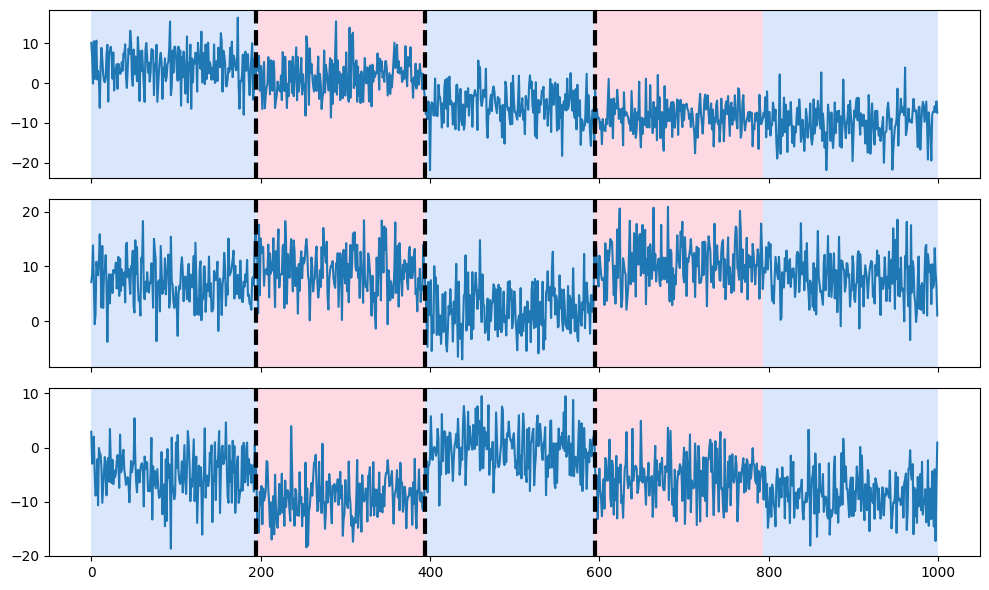

In [1]:
import matplotlib.pyplot as plt
import ruptures as rpt

# generate signal
n_samples, dim, sigma = 1000, 3, 4
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

# detection
algo = rpt.Pelt(model="rbf").fit(signal)
result = algo.predict(pen=10)

# display
rpt.display(signal, bkps, result)
plt.show()

In [3]:
signal

array([[ 10.07424699,   7.14426857,   2.91599708],
       [  6.6118908 ,   8.42353698,  -2.98348319],
       [ -0.15147969,  13.87853978,   0.44981975],
       ...,
       [ -7.27182356,   9.00472951, -17.2330832 ],
       [ -4.59753195,   6.62874572,  -7.40908966],
       [ -7.44211543,   1.03148856,   0.91209737]], shape=(1000, 3))

In [4]:
import yfinance as yf

In [88]:
data = yf.download(tickers = ["SPY"], start="2000-01-01", period="13y", interval="1d")

/var/folders/1d/dkqlxg7d3yv8ccfw3vkrtnsm0000gn/T/ipykernel_67536/1946267133.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers = ["SPY"], start="2000-01-01", period="13y", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [89]:
spy_data = data['Close']
spy_returns = data['Close'].pct_change().dropna()
spy_returns_np = spy_returns.to_numpy()

In [90]:
spy_returns.index[[0, 50, 100]]

DatetimeIndex(['2000-01-04', '2000-03-16', '2000-05-26'], dtype='datetime64[ns]', name='Date', freq=None)

In [91]:
algo = rpt.Pelt(model="normal").fit(spy_returns_np) # rbf
*result, num_samples = algo.predict(pen=100)

# display
# rpt.display(spy_returns_np, np.array([]), result)
# plt.show()

/Users/willneuner/Desktop/FINTECH545/.venv/lib/python3.12/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


In [92]:
spy_data.index[result]

DatetimeIndex(['2003-08-05', '2007-07-19', '2008-09-11', '2009-04-09'], dtype='datetime64[ns]', name='Date', freq=None)

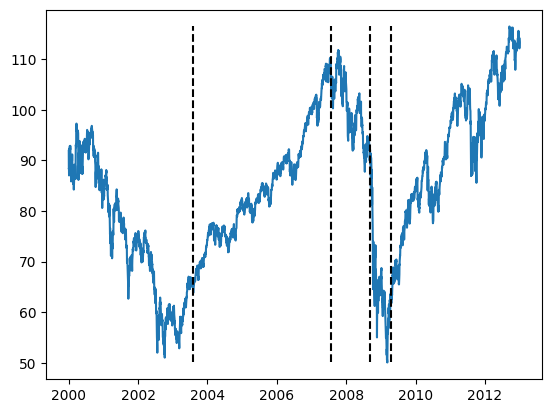

In [93]:
plt.plot(spy_data)
plt.vlines(spy_returns.index[result], ymin=min(spy_data.SPY), ymax=max(spy_data.SPY), colors=["black"]*len(result), linestyles=["--"]*len(result))
plt.show()

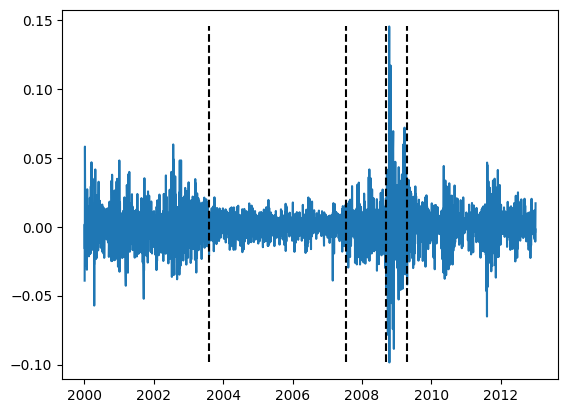

In [94]:
plt.plot(spy_returns)
plt.vlines(spy_returns.index[result], ymin=min(spy_returns_np), ymax=max(spy_returns_np), colors=["black"]*len(result), linestyles=["--"]*len(result))
plt.show()